# 🚀 QuantEval Quick Start / 快速开始

Welcome to QuantEval! This notebook is your first stop in the world of A-share quant research. 📈

We use synthetic market data here so it runs reliably everywhere—even if you don't have an internet connection right now.

欢迎来到 QuantEval！本 Notebook 是你进入 A 股量化研究世界的第一站。📈

由于这里使用了合成的模拟行情数据，所以它在任何环境下都能稳定执行（即便你现在没连网也没关系）。


In [1]:
import numpy as np
import pandas as pd

from quanteval import Backtester, DualMAStrategy

/root/miniconda3/lib/python3.13/site-packages/py_mini_racer/py_mini_racer.py:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### 1. 🏗️ Setup / 环境准备

Let's import our tools. We'll use `pandas` for data and `quanteval` for the heavy lifting.

先导入各种工具。我们会用 `pandas` 理数据，剩下的重活累活交给 `quanteval`。🧠


### 2. 🏪 Data Loading / 加载数据

We'll generate some realistic stock data for demonstration. 💹

这里我们模拟一些股票数据来演练一下。💹


In [2]:
index = pd.date_range('2022-01-03', periods=240, freq='B')
close = pd.Series(100 + np.linspace(0, 25, len(index)) + np.sin(np.arange(len(index)) / 6) * 2, index=index)
data = pd.DataFrame({
    'Open': close * 0.99,
    'High': close * 1.01,
    'Low': close * 0.98,
    'Close': close,
    'Volume': np.linspace(1000, 1800, len(index)),
    'Amount': close * 1000,
}, index=index)
data['Ret'] = data['Close'].pct_change().fillna(0.0)
data.head()

,Open,High,Low,Close,Volume,Amount,Ret
2022-01-03,99.000000,101.000000,98.000000,100.000000,1000.000000,100000.000000,0.000000
2022-01-04,99.432031,101.440759,98.427667,100.436395,1003.347280,100436.394776,0.004364
2022-01-05,99.854958,101.872230,98.846323,100.863594,1006.694561,100863.594415,0.004253
2022-01-06,100.259932,102.285385,99.247205,101.272659,1010.041841,101272.658609,0.004056
2022-01-07,100.638598,102.671701,99.622047,101.655150,1013.389121,101655.149648,0.003777


### 3. 🔥 Run the Backtest! / 开启回测！

We'll use a **Dual Moving Average** strategy (fast 10 vs slow 40). 🧠

我们要运行一个**双均线策略**（10日均线 vs 40日均线）。🧠


In [3]:
strategy = DualMAStrategy(fast_window=10, slow_window=40)
results = Backtester(strategy=strategy, data=data, transaction_costs=True).run()
results.summary()

total_return              0.110650
annual_return             0.116493
annual_volatility         0.027858
max_drawdown             -0.020805
max_drawdown_duration    29.000000
sharpe_ratio              3.104801
sortino_ratio             8.391674
calmar_ratio              5.599166
num_trades                5.000000
win_rate                  1.000000
profit_loss_ratio              NaN
avg_trade_duration       45.800000
benchmark_return          0.265269
alpha                    -0.163748
information_ratio        -6.003504
dtype: float64

### 4. 🎨 Plot Results / 可视化结果

Finally, let's see how our strategy performed over time. 📊

最后来看看我们的收益曲线长啥样。📊


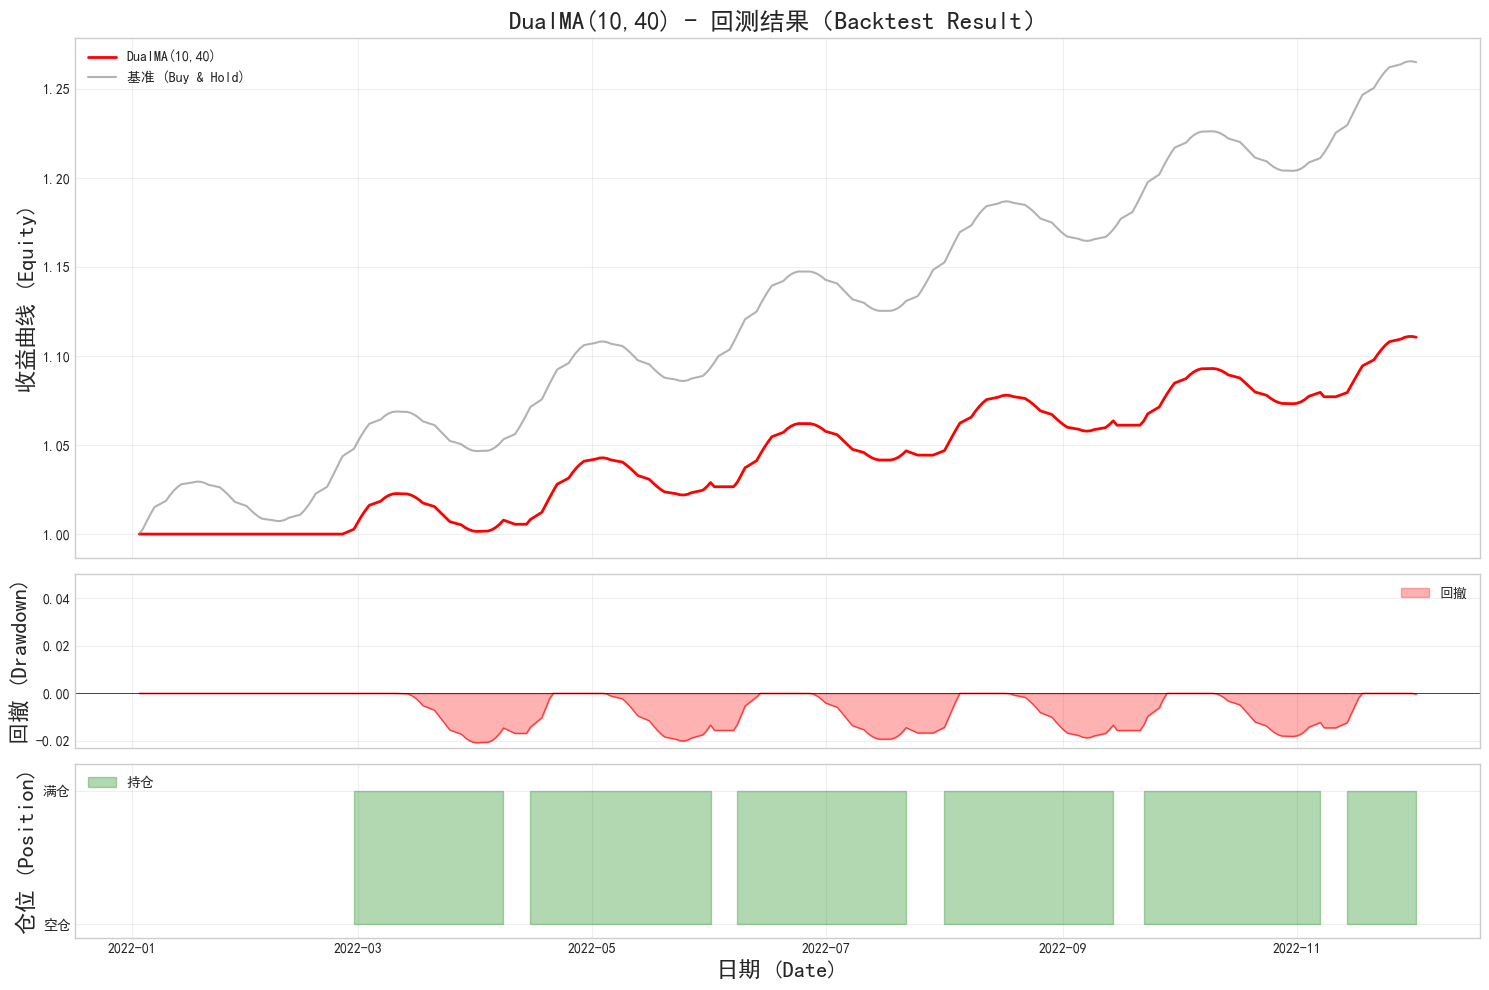

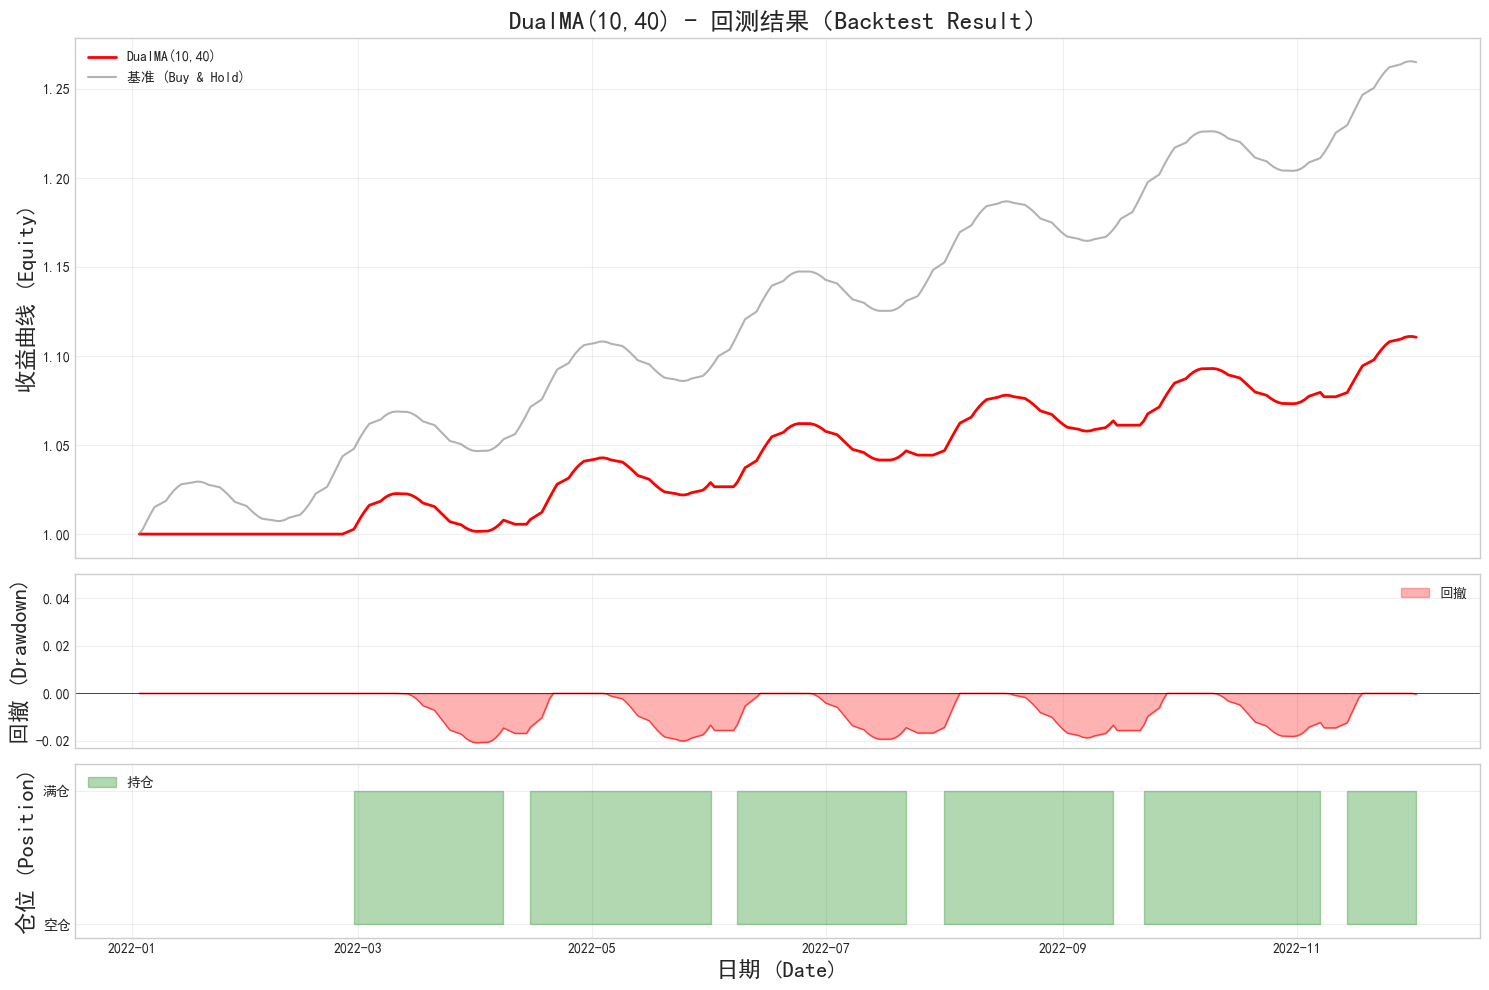

In [4]:
results.plot()